# Multimodal Fashion Product Classification

This notebook implements a multimodal deep learning system for classifying fashion products into 90 categories.

The system combines:

- **EfficientNetV2B0** for image feature extraction
- **DistilBERT** for leakage-controlled text feature extraction
- A dense neural network for multimodal feature fusion

The final multimodal model achieved:

- **91.42% test accuracy**
- **99.78% Top-5 accuracy**
- **91.27% weighted F1-score**

The fusion model outperformed both the image-only and text-only models.

## 1. Environment Setup

This section mounts Google Drive, installs the required libraries, imports dependencies, sets random seeds for reproducibility, and defines the project paths.

Keras 3 is used for the image and fusion models, while legacy `tf_keras` is used to reconstruct the previously trained DistilBERT classifier.

In [49]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Project Configuration

This section defines the project directories, pretrained model paths, dataset locations, and output folders used throughout the notebook.

In [50]:
!pip install -q transformers==4.47.1 tf-keras

In [51]:
import os
import glob
import pickle
import random

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

import keras as keras3
import tf_keras as keras2

from transformers import (
    DistilBertTokenizerFast,
    TFAutoModel
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Keras 3 version:", keras3.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Keras 3 version: 3.13.2
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [52]:
PROJECT_DIR = "/content/drive/MyDrive/fashion_multimodal_project"
OUTPUT_DIR = "/content/drive/MyDrive/Fashion_Project"

MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")

TRAIN_PATH = os.path.join(PROJECT_DIR, "train.csv")
VAL_PATH = os.path.join(PROJECT_DIR, "val.csv")
TEST_PATH = os.path.join(PROJECT_DIR, "test.csv")

LABEL_ENCODER_PATH = (
    "/content/drive/MyDrive/"
    "fashion_multimodal_project/"
    "label_encoder.pkl"
)

IMAGE_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_image_finetuned_best.keras"
)

TEXT_WEIGHTS_PATH = os.path.join(
    PROJECT_DIR,
    "distilbert_text_safe_stage1_best.weights.h5"
)

FUSION_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "multimodal_fusion_best.keras"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Train file exists:", os.path.exists(TRAIN_PATH))
print("Validation file exists:", os.path.exists(VAL_PATH))
print("Test file exists:", os.path.exists(TEST_PATH))
print("Label encoder exists:", os.path.exists(LABEL_ENCODER_PATH))
print("Image model exists:", os.path.exists(IMAGE_MODEL_PATH))
print("Text weights exist:", os.path.exists(TEXT_WEIGHTS_PATH))
print("Fusion model exists:", os.path.exists(FUSION_MODEL_PATH))

Project directory: /content/drive/MyDrive/fashion_multimodal_project
Train file exists: True
Validation file exists: True
Test file exists: True
Label encoder exists: True
Image model exists: True
Text weights exist: True
Fusion model exists: True


## 3. Load Data Splits and Label Encoder

The predefined training, validation, and test splits are loaded from Google Drive.

Using fixed splits ensures that the image-only, text-only, and multimodal models are evaluated on the same samples.

The saved label encoder converts the target `articleType` categories into numerical class labels.

In [53]:
# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# Load label encoder
with open(LABEL_ENCODER_PATH, "rb") as file:
    label_encoder = pickle.load(file)

NUM_CLASSES = len(label_encoder.classes_)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
print("Number of classes:", NUM_CLASSES)

Training samples: 30814
Validation samples: 4402
Test samples: 8804
Number of classes: 90


In [54]:
with open(LABEL_ENCODER_PATH, "rb") as file:
    label_encoder = pickle.load(file)

NUM_CLASSES = len(label_encoder.classes_)

print("Encoder path:", LABEL_ENCODER_PATH)
print("Number of classes:", NUM_CLASSES)

Encoder path: /content/drive/MyDrive/fashion_multimodal_project/label_encoder.pkl
Number of classes: 90


In [55]:
dataset_classes = set(train_df["articleType"].unique())
encoder_classes = set(label_encoder.classes_)

print("Dataset class count:", len(dataset_classes))
print("Encoder class count:", len(encoder_classes))
print("Classes match:", dataset_classes == encoder_classes)

Dataset class count: 90
Encoder class count: 90
Classes match: True


## 4. Create Leakage-Controlled Text

The prediction target is `articleType`. To prevent target leakage, fields that directly reveal or strongly duplicate the product category are excluded from the text input.

The following fields are not used:

- `articleType`
- `subCategory`
- `productDisplayName`

The text representation is constructed using only:

- `gender`
- `masterCategory`
- `baseColour`
- `season`
- `year`
- `usage`

This creates a more realistic text-classification task and prevents the model from reading the answer directly from the input.

In [56]:
SAFE_TEXT_COLUMNS = [
    "gender",
    "masterCategory",
    "baseColour",
    "season",
    "year",
    "usage"
]


def build_safe_text(dataframe):
    df = dataframe.copy()

    for column in SAFE_TEXT_COLUMNS:
        df[column] = df[column].fillna("").astype(str)

    df["text_safe"] = (
        "gender: " + df["gender"] + ". "
        + "master category: " + df["masterCategory"] + ". "
        + "colour: " + df["baseColour"] + ". "
        + "season: " + df["season"] + ". "
        + "year: " + df["year"] + ". "
        + "usage: " + df["usage"]
    )

    return df


train_df = build_safe_text(train_df)
val_df = build_safe_text(val_df)
test_df = build_safe_text(test_df)

train_df[["articleType", "text_safe"]].head()

,articleType,text_safe
0,Casual Shoes,gender: Women. master category: Footwear. colo...
1,Belts,gender: Men. master category: Accessories. col...
2,Shorts,gender: Men. master category: Apparel. colour:...
3,Watches,gender: Men. master category: Accessories. col...
4,Socks,gender: Men. master category: Accessories. col...


## 5. Download and Prepare Product Images

The Fashion Product Images Small dataset is downloaded from Kaggle and extracted into the Colab runtime.

Each metadata record is matched to its corresponding image using the product ID. Missing image files are checked before creating the multimodal datasets.

Kaggle credentials are accessed through Colab Secrets and are not written directly in the notebook.

In [57]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get(
    "KAGGLE_USERNAME"
)

os.environ["KAGGLE_KEY"] = userdata.get(
    "KAGGLE_KEY"
)

print("Kaggle credentials configured.")

Kaggle credentials configured.


In [58]:
DATASET_DIR = "/content/fashion_dataset"
IMAGE_DIR = os.path.join(DATASET_DIR, "images")
ZIP_PATH = os.path.join(
    DATASET_DIR,
    "fashion-product-images-small.zip"
)

os.makedirs(DATASET_DIR, exist_ok=True)

if not os.path.exists(IMAGE_DIR):
    !kaggle datasets download \
        -d paramaggarwal/fashion-product-images-small \
        -p /content/fashion_dataset

    !unzip -q \
        /content/fashion_dataset/fashion-product-images-small.zip \
        -d /content/fashion_dataset
else:
    print("Dataset is already extracted.")

Dataset is already extracted.


In [59]:
print("Image directory exists:", os.path.exists(IMAGE_DIR))

image_files = glob.glob(
    os.path.join(IMAGE_DIR, "*.jpg")
)

print("Number of image files:", len(image_files))

Image directory exists: True
Number of image files: 44441


In [60]:
def add_image_paths(dataframe):
    df = dataframe.copy()

    df["image_path"] = (
        df["id"]
        .astype(str)
        .apply(
            lambda product_id: os.path.join(
                IMAGE_DIR,
                f"{product_id}.jpg"
            )
        )
    )

    return df


train_df = add_image_paths(train_df)
val_df = add_image_paths(val_df)
test_df = add_image_paths(test_df)

train_df[["id", "image_path"]].head()

,id,image_path
0,46825,/content/fashion_dataset/images/46825.jpg
1,42954,/content/fashion_dataset/images/42954.jpg
2,22584,/content/fashion_dataset/images/22584.jpg
3,51581,/content/fashion_dataset/images/51581.jpg
4,18223,/content/fashion_dataset/images/18223.jpg


In [61]:
def count_missing_images(dataframe):
    return (
        ~dataframe["image_path"]
        .apply(os.path.exists)
    ).sum()


print(
    "Missing training images:",
    count_missing_images(train_df)
)

print(
    "Missing validation images:",
    count_missing_images(val_df)
)

print(
    "Missing test images:",
    count_missing_images(test_df)
)

Missing training images: 0
Missing validation images: 0
Missing test images: 0


## 6. Tokenization and Multimodal Data Pipeline

The leakage-controlled text is tokenized using the `distilbert-base-uncased` tokenizer.

Each text input is padded or truncated to 64 tokens.

Images are:

1. Read from disk
2. Decoded as RGB
3. Resized to 224 × 224 pixels
4. Converted to floating-point tensors

The image, token IDs, attention masks, and encoded labels are combined into aligned TensorFlow datasets.

In [62]:
TOKENIZER_NAME = "distilbert-base-uncased"
MAX_LENGTH = 64
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

tokenizer = DistilBertTokenizerFast.from_pretrained(
    TOKENIZER_NAME
)

print("Tokenizer loaded.")

Tokenizer loaded.


In [63]:
def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="np"
    )


train_tokens = tokenize_texts(train_df["text_safe"])
val_tokens = tokenize_texts(val_df["text_safe"])
test_tokens = tokenize_texts(test_df["text_safe"])

print("Training token shape:", train_tokens["input_ids"].shape)
print("Validation token shape:", val_tokens["input_ids"].shape)
print("Test token shape:", test_tokens["input_ids"].shape)

Training token shape: (30814, 64)
Validation token shape: (4402, 64)
Test token shape: (8804, 64)


In [64]:
train_labels = label_encoder.transform(
    train_df["articleType"]
)

val_labels = label_encoder.transform(
    val_df["articleType"]
)

test_labels = label_encoder.transform(
    test_df["articleType"]
)

print("Training labels:", train_labels.shape)
print("Validation labels:", val_labels.shape)
print("Test labels:", test_labels.shape)

Training labels: (30814,)
Validation labels: (4402,)
Test labels: (8804,)


In [65]:
def load_multimodal_sample(
    image_path,
    input_ids,
    attention_mask,
    label
):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    image = tf.cast(
        image,
        tf.float32
    )

    inputs = {
        "image_input": image,
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }

    return inputs, label

In [66]:
def create_multimodal_dataset(
    dataframe,
    tokens,
    labels,
    training=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_path"].astype(str).values,
            tokens["input_ids"],
            tokens["attention_mask"],
            labels
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_multimodal_sample,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [67]:
train_mm_ds = create_multimodal_dataset(
    train_df,
    train_tokens,
    train_labels,
    training=False
)

val_mm_ds = create_multimodal_dataset(
    val_df,
    val_tokens,
    val_labels,
    training=False
)

test_mm_ds = create_multimodal_dataset(
    test_df,
    test_tokens,
    test_labels,
    training=False
)

print("Multimodal datasets created.")

Multimodal datasets created.


In [68]:
sample_inputs, sample_labels = next(
    iter(train_mm_ds)
)

print(
    "Image batch:",
    sample_inputs["image_input"].shape
)

print(
    "Input IDs:",
    sample_inputs["input_ids"].shape
)

print(
    "Attention masks:",
    sample_inputs["attention_mask"].shape
)

print(
    "Labels:",
    sample_labels.shape
)

Image batch: (32, 224, 224, 3)
Input IDs: (32, 64)
Attention masks: (32, 64)
Labels: (32,)


## 7. Restore the Image Feature Extractor

The fine-tuned EfficientNetV2B0 classifier is loaded from Google Drive.

The final classifier output is not used for multimodal fusion. Instead, the named `image_embedding` layer is exposed as a feature extractor.

This layer produces a 256-dimensional visual representation for each product image. The image branch remains frozen during multimodal feature extraction.

In [69]:
image_model = keras3.models.load_model(
    IMAGE_MODEL_PATH,
    compile=False
)

image_feature_extractor = keras3.Model(
    inputs=image_model.inputs,
    outputs=image_model.get_layer(
        "image_embedding"
    ).output,
    name="image_feature_extractor"
)

image_feature_extractor.trainable = False

print("Image model:", image_model.name)
print(
    "Image embedding shape:",
    image_feature_extractor.output_shape
)

Image model: EfficientNetV2_Image_Classifier
Image embedding shape: (None, 256)


In [70]:
sample_image_embeddings = image_feature_extractor(
    sample_inputs["image_input"],
    training=False
)

print(
    "Sample image embeddings:",
    sample_image_embeddings.shape
)

Sample image embeddings: (32, 256)


## 8. Restore the DistilBERT Text Feature Extractor

The leakage-controlled DistilBERT classifier is reconstructed using the same subclassed architecture used during text-model training.

The saved weights are then loaded into the reconstructed model.

The named `text_embedding` layer produces a 256-dimensional representation for each product description. The DistilBERT backbone and text feature extractor remain frozen.

In [71]:
TEXT_MODEL_NAME = "distilbert-base-uncased"

distilbert_backbone_safe = TFAutoModel.from_pretrained(
    TEXT_MODEL_NAME
)

distilbert_backbone_safe.trainable = False

print("DistilBERT backbone loaded.")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


DistilBERT backbone loaded.


In [72]:
class DistilBERTClassifier(keras2.Model):
    def __init__(self, transformer, num_classes):
        super().__init__()

        self.transformer = transformer
        self.dropout_1 = keras2.layers.Dropout(0.3)

        self.text_embedding = keras2.layers.Dense(
            256,
            activation="relu",
            name="text_embedding"
        )

        self.dropout_2 = keras2.layers.Dropout(0.3)

        self.classifier = keras2.layers.Dense(
            num_classes,
            activation="softmax",
            name="text_classifier"
        )

    def call(self, inputs, training=False):
        transformer_outputs = self.transformer(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            training=training
        )

        cls_embedding = (
            transformer_outputs
            .last_hidden_state[:, 0, :]
        )

        x = self.dropout_1(
            cls_embedding,
            training=training
        )

        x = self.text_embedding(x)

        x = self.dropout_2(
            x,
            training=training
        )

        return self.classifier(x)

In [73]:
text_model_safe = DistilBERTClassifier(
    transformer=distilbert_backbone_safe,
    num_classes=NUM_CLASSES
)

sample_text_inputs = {
    "input_ids": sample_inputs["input_ids"],
    "attention_mask": sample_inputs["attention_mask"]
}

sample_predictions = text_model_safe(
    sample_text_inputs,
    training=False
)

print(
    "Prediction shape before loading:",
    sample_predictions.shape
)

Prediction shape before loading: (32, 90)


In [74]:
text_model_safe.load_weights(
    TEXT_WEIGHTS_PATH
)

text_model_safe.trainable = False

print("DistilBERT weights loaded successfully.")

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


DistilBERT weights loaded successfully.


### 8.1 Create the Text Feature Extractor

The pretrained DistilBERT text classifier is restored using the saved weights, and the classification layer is removed to create a feature extractor. The restored model was previously validated with a text-only test accuracy of approximately **55.01%**, and is used here to generate 256-dimensional text embeddings for multimodal fusion.

In [75]:
class TextFeatureExtractor(keras2.Model):
    def __init__(self, trained_text_model):
        super().__init__()

        self.transformer = (
            trained_text_model.transformer
        )

        self.dropout_1 = (
            trained_text_model.dropout_1
        )

        self.text_embedding = (
            trained_text_model.text_embedding
        )

    def call(self, inputs, training=False):
        transformer_outputs = self.transformer(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            training=False
        )

        cls_embedding = (
            transformer_outputs
            .last_hidden_state[:, 0, :]
        )

        x = self.dropout_1(
            cls_embedding,
            training=False
        )

        return self.text_embedding(x)

In [76]:
text_feature_extractor = TextFeatureExtractor(
    text_model_safe
)

text_feature_extractor.trainable = False

sample_text_embeddings = text_feature_extractor(
    sample_text_inputs,
    training=False
)

print(
    "Sample text embeddings:",
    sample_text_embeddings.shape
)

Sample text embeddings: (32, 256)


## 9. Extract and Combine Multimodal Features

Each product is represented using two pretrained feature embeddings:

1. A **256-dimensional EfficientNetV2 image embedding**
2. A **256-dimensional DistilBERT text embedding**

The two embeddings are concatenated to form a **512-dimensional multimodal feature vector**:

$$
\mathbf{z}_{\mathrm{fusion}}
=
[\mathbf{z}_{\mathrm{image}};\mathbf{z}_{\mathrm{text}}]
$$

The image and text embeddings are precomputed independently before fusion. This approach avoids combining models built with Keras 3 and legacy `tf_keras` within a single computation graph while preserving the pretrained representations learned by each modality.

In [77]:
def extract_multimodal_features(dataset, dataset_name="Dataset"):
    image_features_all = []
    text_features_all = []
    labels_all = []

    for step, (batch_inputs, batch_labels) in enumerate(dataset):
        # Image embeddings: (batch_size, 256)
        image_features = image_feature_extractor(
            batch_inputs["image_input"],
            training=False
        )

        # Text embeddings: (batch_size, 256)
        text_inputs = {
            "input_ids": batch_inputs["input_ids"],
            "attention_mask": batch_inputs["attention_mask"]
        }

        text_features = text_feature_extractor(
            text_inputs,
            training=False
        )

        image_features_all.append(image_features.numpy())
        text_features_all.append(text_features.numpy())
        labels_all.append(batch_labels.numpy())

        if (step + 1) % 100 == 0:
            print(f"{dataset_name}: processed {step + 1} batches")

    image_features_all = np.concatenate(
        image_features_all,
        axis=0
    ).astype("float32")

    text_features_all = np.concatenate(
        text_features_all,
        axis=0
    ).astype("float32")

    labels_all = np.concatenate(
        labels_all,
        axis=0
    ).astype("int32")

    # Concatenated multimodal representation: 256 + 256 = 512
    multimodal_features = np.concatenate(
        [image_features_all, text_features_all],
        axis=1
    ).astype("float32")

    print(f"\n{dataset_name} extraction complete")
    print("Image features:", image_features_all.shape)
    print("Text features:", text_features_all.shape)
    print("Multimodal features:", multimodal_features.shape)
    print("Labels:", labels_all.shape)

    return (
        multimodal_features,
        labels_all,
        image_features_all,
        text_features_all
    )

In [78]:
(
    X_val_mm,
    y_val_mm,
    X_val_image,
    X_val_text
) = extract_multimodal_features(
    val_mm_ds,
    dataset_name="Validation"
)

Validation: processed 100 batches

Validation extraction complete
Image features: (4402, 256)
Text features: (4402, 256)
Multimodal features: (4402, 512)
Labels: (4402,)


In [79]:
assert X_val_mm.shape == (4402, 512)
assert X_val_image.shape == (4402, 256)
assert X_val_text.shape == (4402, 256)
assert y_val_mm.shape == (4402,)

print("Validation feature shapes are correct.")

Validation feature shapes are correct.


In [80]:
(
    X_train_mm,
    y_train_mm,
    X_train_image,
    X_train_text
) = extract_multimodal_features(
    train_mm_ds,
    dataset_name="Training"
)

Training: processed 100 batches
Training: processed 200 batches
Training: processed 300 batches
Training: processed 400 batches
Training: processed 500 batches
Training: processed 600 batches
Training: processed 700 batches
Training: processed 800 batches
Training: processed 900 batches

Training extraction complete
Image features: (30814, 256)
Text features: (30814, 256)
Multimodal features: (30814, 512)
Labels: (30814,)


In [81]:
(
    X_test_mm,
    y_test_mm,
    X_test_image,
    X_test_text
) = extract_multimodal_features(
    test_mm_ds,
    dataset_name="Test"
)

Test: processed 100 batches
Test: processed 200 batches

Test extraction complete
Image features: (8804, 256)
Text features: (8804, 256)
Multimodal features: (8804, 512)
Labels: (8804,)


In [82]:
print(
    "Training:",
    X_train_mm.shape,
    y_train_mm.shape
)

print(
    "Validation:",
    X_val_mm.shape,
    y_val_mm.shape
)

print(
    "Test:",
    X_test_mm.shape,
    y_test_mm.shape
)

assert X_train_mm.shape[1] == 512
assert X_val_mm.shape[1] == 512
assert X_test_mm.shape[1] == 512

print("All multimodal feature matrices are ready.")

Training: (30814, 512) (30814,)
Validation: (4402, 512) (4402,)
Test: (8804, 512) (8804,)
All multimodal feature matrices are ready.


## 10. Train the Multimodal Fusion Classifier

The concatenated 512-dimensional feature vector is passed through a fully connected neural network.

The fusion classifier contains:

- Batch normalization
- Dense layer with 256 units and ReLU activation
- Dropout of 0.4
- Dense layer with 128 units and ReLU activation
- Dropout of 0.3
- Softmax output layer with 90 classes

The image and text branches remain frozen. Only the fusion classifier is trained.

In [83]:
fusion_model = keras3.Sequential(
    [
        keras3.layers.Input(shape=(512,), name="multimodal_features"),

        keras3.layers.BatchNormalization(),

        keras3.layers.Dense(
            256,
            activation="relu",
            name="fusion_dense_1"
        ),

        keras3.layers.Dropout(0.4),

        keras3.layers.Dense(
            128,
            activation="relu",
            name="fusion_dense_2"
        ),

        keras3.layers.Dropout(0.3),

        keras3.layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            name="fusion_classifier"
        )
    ],
    name="multimodal_fusion_classifier"
)

fusion_model.summary()

Model: "multimodal_fusion_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dense_1 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dense_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_classifier (Dense)       │ (None, 90)             │        11,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,882 (694.85 KB)

 Trainable params: 176,858 (690.85 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [84]:
fusion_model.compile(
    optimizer=keras3.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras3.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras3.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        keras3.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

In [85]:
fusion_callbacks = [
    keras3.callbacks.ModelCheckpoint(
        filepath=FUSION_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras3.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras3.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [86]:
fusion_history = fusion_model.fit(
    X_train_mm,
    y_train_mm,
    validation_data=(X_val_mm, y_val_mm),
    epochs=30,
    batch_size=64,
    callbacks=fusion_callbacks,
    verbose=1
)

Epoch 1/30
482/482 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6814 - loss: 1.4050 - top_5_accuracy: 0.8327
Epoch 1: val_accuracy improved from None to 0.88301, saving model to /content/drive/MyDrive/Fashion_Project/models/multimodal_fusion_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fashion_Project/models/multimodal_fusion_best.keras
482/482 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7914 - loss: 0.8224 - top_5_accuracy: 0.9311 - val_accuracy: 0.8830 - val_loss: 0.3732 - val_top_5_accuracy: 0.9932 - learning_rate: 0.0010
Epoch 2/30
474/482 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8686 - loss: 0.4259 - top_5_accuracy: 0.9870
Epoch 2: val_accuracy improved from 0.88301 to 0.89755, saving model to /content/drive/MyDrive/Fashion_Project/models/multimodal_fusion_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Fashion_Project/models/multimodal_fusion_best.keras
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8761 - loss: 0.39

## 11. Evaluate the Best Fusion Model

The checkpoint with the highest validation accuracy is restored and evaluated on the held-out test set.

The evaluation reports:

- Test loss
- Top-1 accuracy
- Top-5 accuracy
- Per-class precision
- Per-class recall
- Per-class F1-score
- Macro and weighted averages

In [87]:
best_fusion_model = keras3.models.load_model(
    FUSION_MODEL_PATH
)

test_results = best_fusion_model.evaluate(
    X_test_mm,
    y_test_mm,
    batch_size=64,
    verbose=1,
    return_dict=True
)

print("\nFusion test results")
for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9144 - loss: 0.2917 - top_5_accuracy: 0.9977

Fusion test results
accuracy: 0.9144
loss: 0.2917
top_5_accuracy: 0.9977


In [88]:
y_test_prob = best_fusion_model.predict(
    X_test_mm,
    batch_size=64,
    verbose=1
)

y_test_pred = np.argmax(y_test_prob, axis=1)

print("Probability shape:", y_test_prob.shape)
print("Prediction shape:", y_test_pred.shape)

138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Probability shape: (8804, 90)
Prediction shape: (8804,)


## 12. Final Model Results

The multimodal fusion model achieved the following performance on the held-out test set:

| Model | Test Accuracy | Top-5 Accuracy |
|---|---:|---:|
| DistilBERT text-only | 55.01% | 91.22% |
| EfficientNetV2B0 image-only | 87.37% | 99.38% |
| **Multimodal fusion** | **91.42%** | **99.78%** |

The multimodal model improved Top-1 test accuracy by **4.05 percentage points** compared with the image-only model.

Its weighted test metrics were:

- Precision: **91.34%**
- Recall: **91.42%**
- F1-score: **91.27%**

The results demonstrate that the leakage-controlled product metadata provides complementary information to the image representation.

In [89]:
from sklearn.metrics import classification_report

class_names = [str(name) for name in label_encoder.classes_]

fusion_report = classification_report(
    y_test_mm,
    y_test_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(fusion_report)

                        precision    recall  f1-score   support

    Accessory Gift Set     1.0000    1.0000    1.0000        19
             Backpacks     0.9595    0.9793    0.9693       145
                Bangle     0.7647    0.7647    0.7647        17
             Bath Robe     1.0000    1.0000    1.0000         4
                 Belts     1.0000    1.0000    1.0000       163
                Boxers     0.7500    0.9000    0.8182        10
                   Bra     0.9592    0.9895    0.9741        95
              Bracelet     0.6667    0.6154    0.6400        13
                Briefs     0.9706    0.9706    0.9706       170
             Camisoles     0.7143    0.6250    0.6667         8
                Capris     0.7714    0.7714    0.7714        35
                  Caps     0.9818    0.9474    0.9643        57
          Casual Shoes     0.9521    0.9438    0.9479       569
              Churidar     0.6667    0.3333    0.4444         6
              Clutches     0.8298    0.

## 13. Save Evaluation Results

The classification report, training history, and test predictions are saved to Google Drive for later use in the GitHub repository.

In [90]:
REPORT_PATH = os.path.join(
    RESULTS_DIR,
    "multimodal_fusion_classification_report.txt"
)

with open(REPORT_PATH, "w") as file:
    file.write("Multimodal Fusion Test Results\n")
    file.write("=" * 40 + "\n\n")

    for metric, value in test_results.items():
        file.write(
            f"{metric}: {value:.4f}\n"
        )

    file.write("\nClassification Report\n")
    file.write("=" * 40 + "\n")
    file.write(fusion_report)

print("Report saved to:", REPORT_PATH)

Report saved to: /content/drive/MyDrive/Fashion_Project/results/multimodal_fusion_classification_report.txt


In [91]:
history_df = pd.DataFrame(fusion_history.history)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "multimodal_fusion_training_history.csv"
)

history_df.to_csv(HISTORY_PATH, index=False)

print("History saved to:", HISTORY_PATH)

History saved to: /content/drive/MyDrive/Fashion_Project/results/multimodal_fusion_training_history.csv


In [92]:
prediction_results = pd.DataFrame({
    "true_label_id": y_test_mm,
    "predicted_label_id": y_test_pred,
    "true_class": label_encoder.inverse_transform(
        y_test_mm
    ),
    "predicted_class": label_encoder.inverse_transform(
        y_test_pred
    ),
    "confidence": np.max(
        y_test_prob,
        axis=1
    ),
    "correct": (
        y_test_mm == y_test_pred
    )
})

PREDICTIONS_PATH = os.path.join(
    RESULTS_DIR,
    "multimodal_fusion_predictions.csv"
)

prediction_results.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print(
    "Predictions saved to:",
    PREDICTIONS_PATH
)

prediction_results.head()

Predictions saved to: /content/drive/MyDrive/Fashion_Project/results/multimodal_fusion_predictions.csv


,true_label_id,predicted_label_id,true_class,predicted_class,confidence,correct
0,42,42,Kurtas,Kurtas,0.643508,True
1,84,84,Trousers,Trousers,0.999995,True
2,72,72,Sports Shoes,Sports Shoes,0.996188,True
3,42,42,Kurtas,Kurtas,0.998634,True
4,86,86,Tshirts,Tshirts,0.999992,True


## 14. Training Behaviour

The training and validation curves are used to inspect model convergence and overfitting.

The highest validation accuracy was achieved at epoch 10. Training stopped at epoch 15, and the weights from the best epoch were restored.

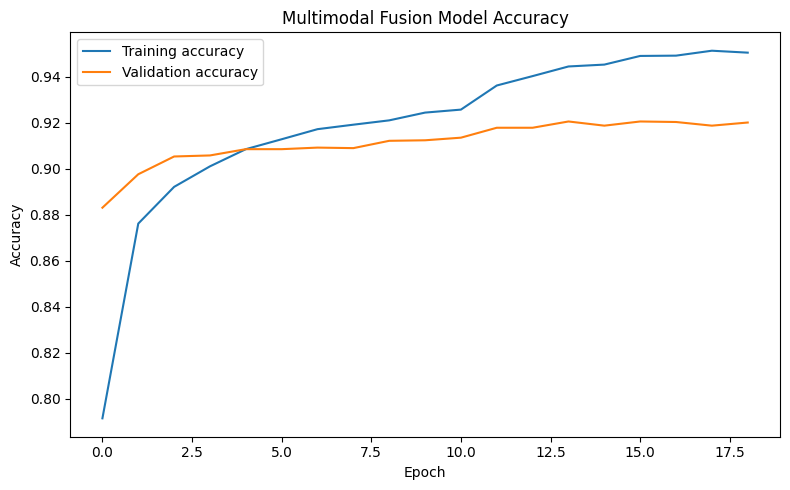

Saved to: /content/drive/MyDrive/Fashion_Project/results/fusion_accuracy_curve.png


In [93]:
plt.figure(figsize=(8, 5))

plt.plot(
    fusion_history.history["accuracy"],
    label="Training accuracy"
)

plt.plot(
    fusion_history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multimodal Fusion Model Accuracy")
plt.legend()
plt.tight_layout()

ACCURACY_PLOT_PATH = os.path.join(
    RESULTS_DIR,
    "fusion_accuracy_curve.png"
)

plt.savefig(
    ACCURACY_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", ACCURACY_PLOT_PATH)

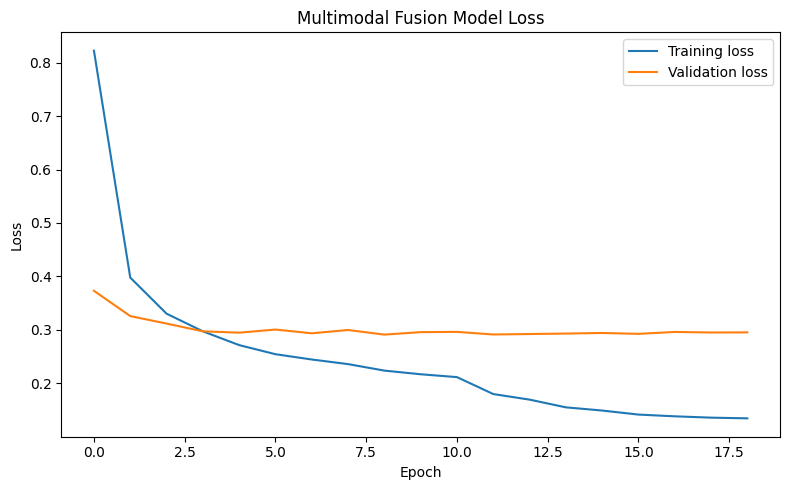

Saved to: /content/drive/MyDrive/Fashion_Project/results/fusion_loss_curve.png


In [94]:
plt.figure(figsize=(8, 5))

plt.plot(
    fusion_history.history["loss"],
    label="Training loss"
)

plt.plot(
    fusion_history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multimodal Fusion Model Loss")
plt.legend()
plt.tight_layout()

LOSS_PLOT_PATH = os.path.join(
    RESULTS_DIR,
    "fusion_loss_curve.png"
)

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", LOSS_PLOT_PATH)

## 15. Class-Level Error Analysis

The confusion matrix and classification report are used to examine the model's performance across the 90 product categories.

The model performs particularly well for visually distinctive categories such as:

- Watches
- Sunglasses
- Sports Shoes
- Sarees
- Socks
- Earrings

More difficult categories include:

- Jeggings
- Messenger Bag
- Face Wash and Cleanser
- Tunics
- Flats

Some of these weaker categories have relatively few test examples, while others share strong visual similarities with related product classes.

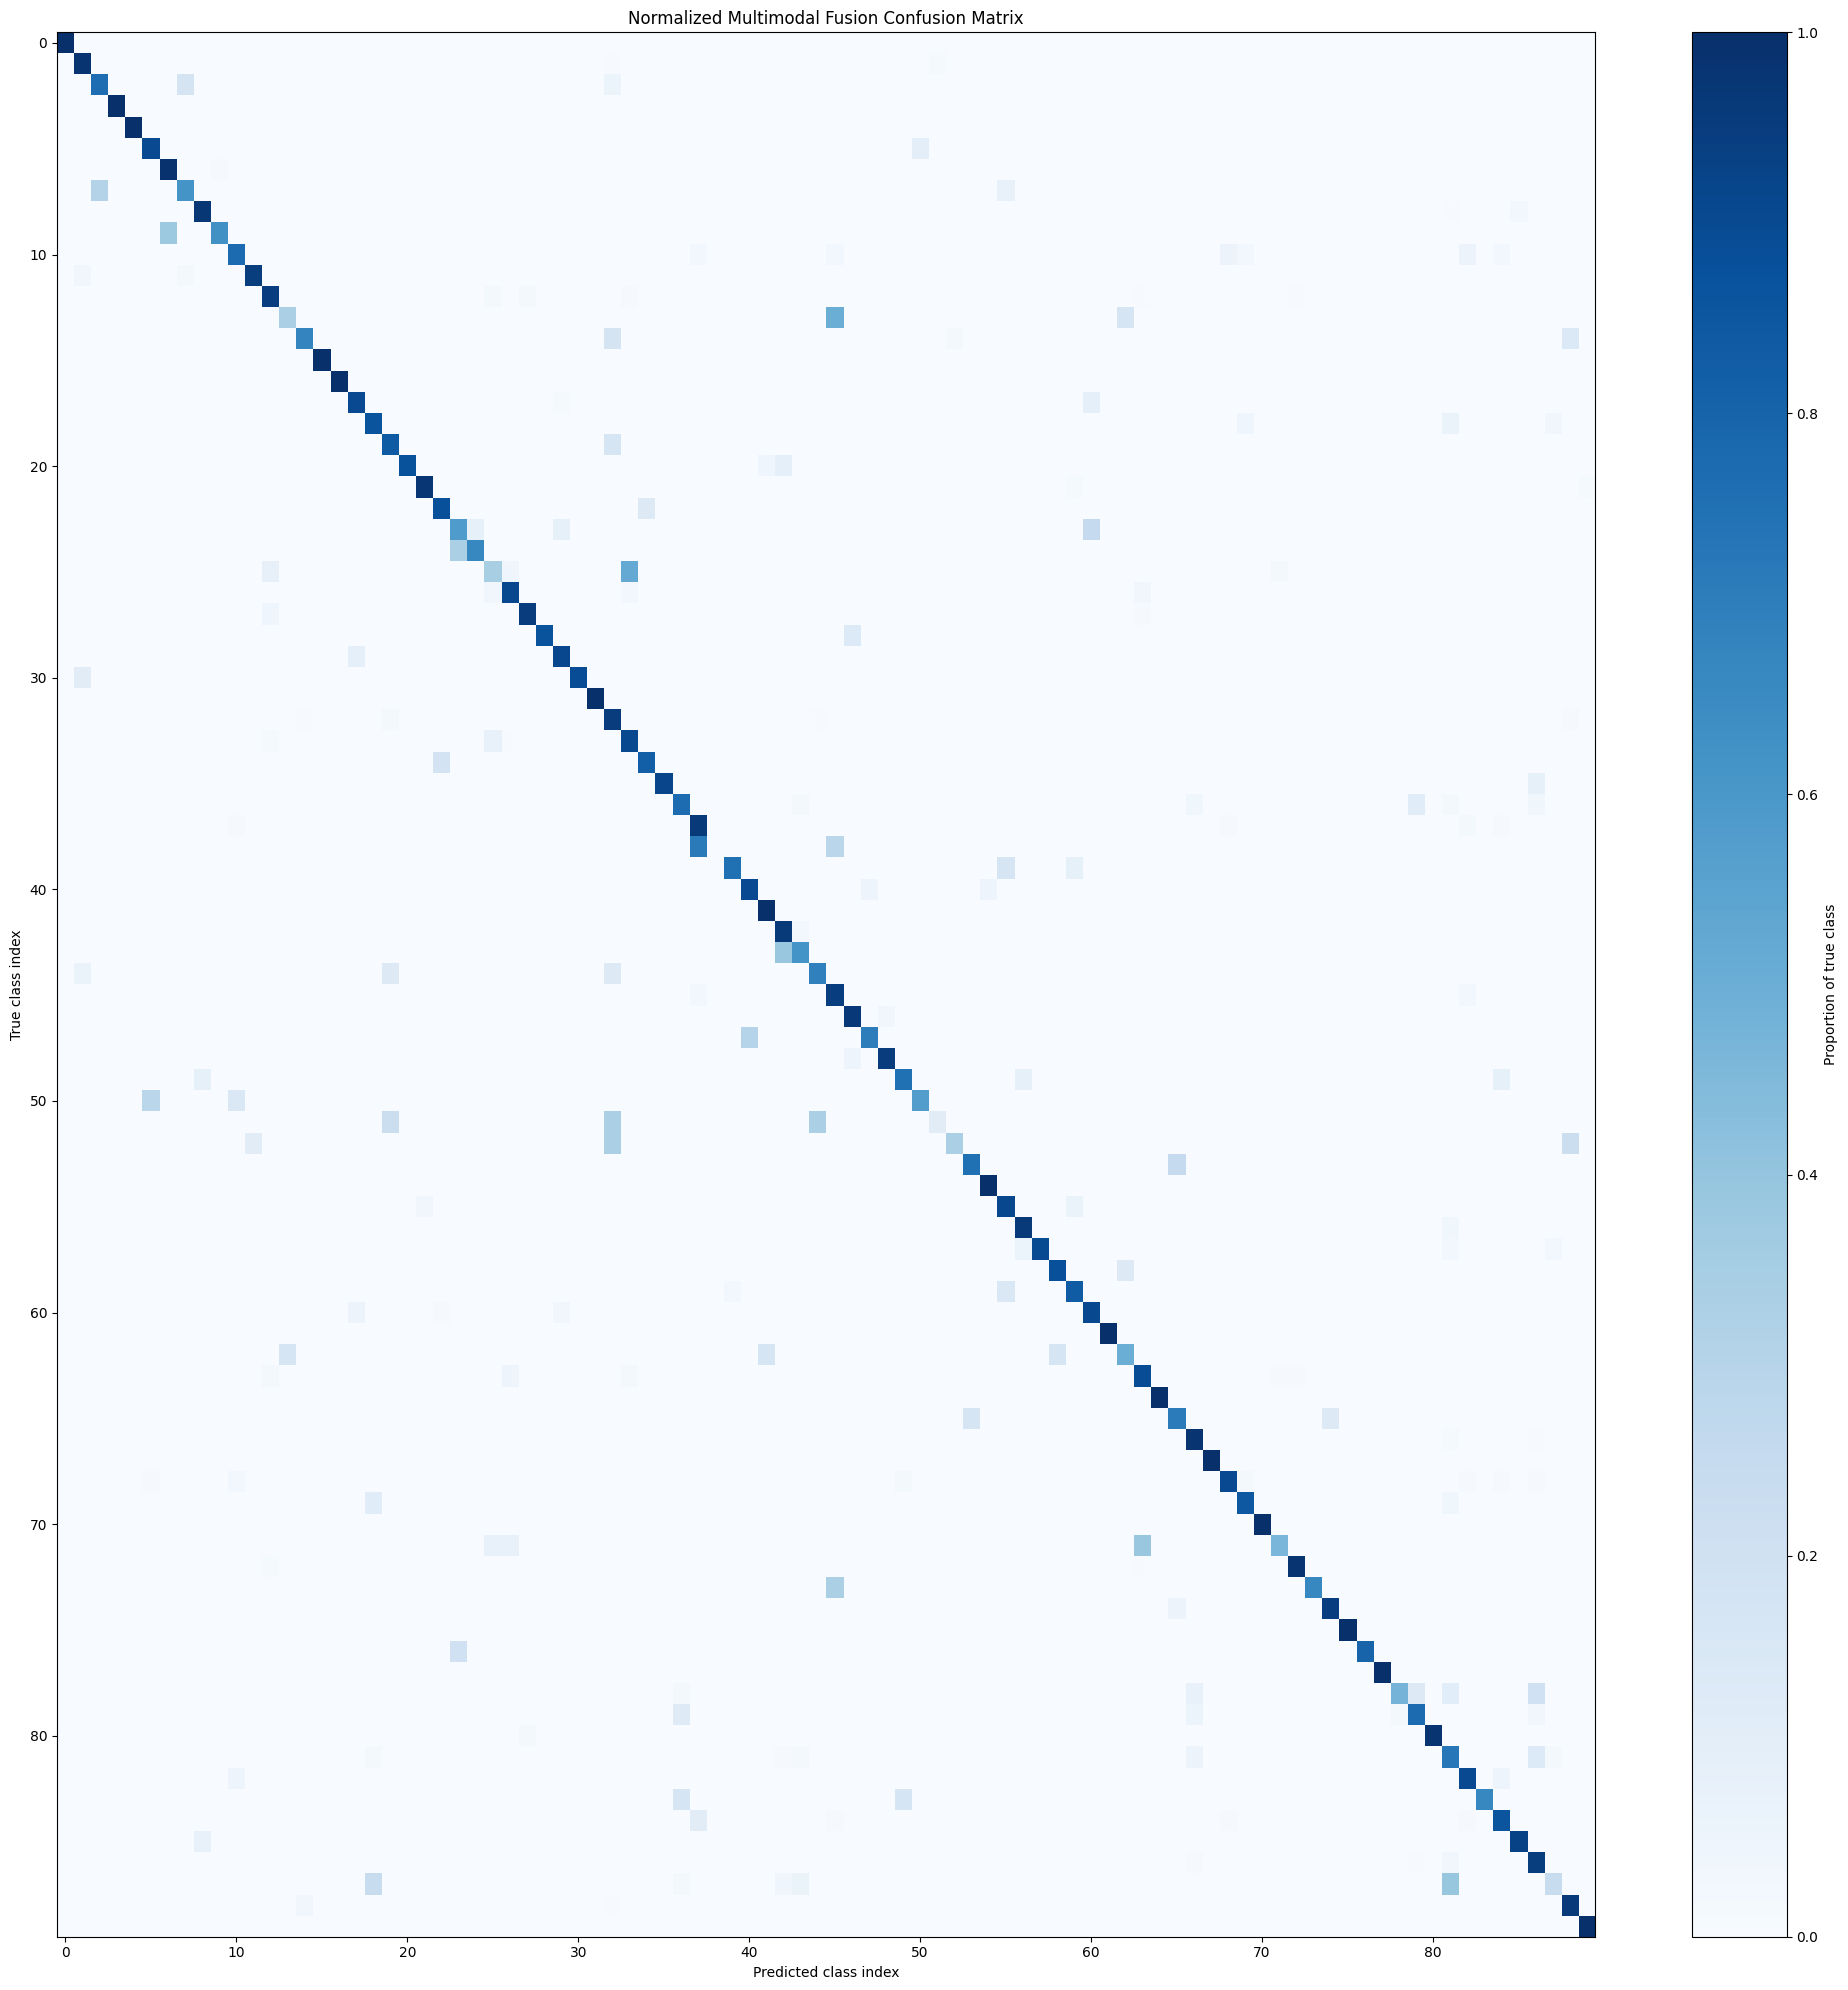

Saved to: /content/drive/MyDrive/Fashion_Project/results/fusion_confusion_matrix.png


In [95]:
cm = confusion_matrix(
    y_test_mm,
    y_test_pred,
    normalize="true"
)

plt.figure(figsize=(20, 20))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues",
    aspect="auto"
)

plt.title(
    "Normalized Multimodal Fusion Confusion Matrix"
)

plt.colorbar(
    label="Proportion of true class"
)

plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.tight_layout()

CONFUSION_MATRIX_PATH = os.path.join(
    RESULTS_DIR,
    "fusion_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", CONFUSION_MATRIX_PATH)

## 16. Conclusion

This project developed a multimodal fashion product classification system combining EfficientNetV2B0 visual embeddings with leakage-controlled DistilBERT text embeddings.

The image and text branches each generated a 256-dimensional feature vector. These representations were concatenated to form a 512-dimensional multimodal feature vector, which was passed to a dense fusion classifier.

The final model achieved:

- **91.42% test accuracy**
- **99.78% Top-5 accuracy**
- **91.27% weighted F1-score**

The multimodal system outperformed:

- The image-only model by **4.05 percentage points**
- The text-only model by **36.41 percentage points**

These results show that combining visual and textual product information produces a stronger representation than using either modality independently.